In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('Zomato-data.csv')

In [17]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [18]:
df.shape

(148, 7)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [20]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [23]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [22]:
def handle_rate(val):
    l = str(val).split('/')
    l=l[0]
    return float(l)

df['rate'] = df['rate'].apply(handle_rate)

In [21]:
listed_in = df['listed_in(type)'].unique().tolist()
listed_in

['Buffet', 'Cafes', 'other', 'Dining']

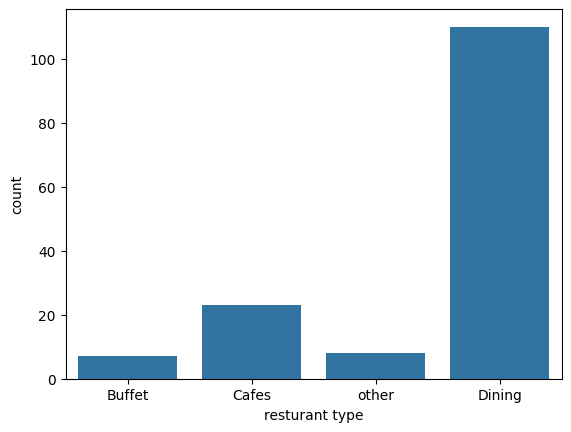

In [24]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("resturant type")
plt.show()

Text(0, 0.5, 'Votes')

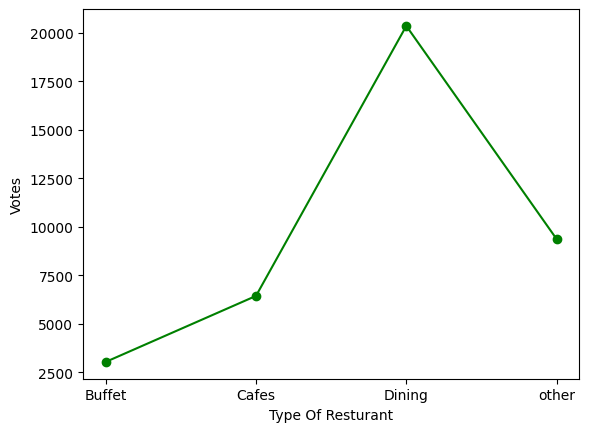

In [29]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
res = pd.DataFrame({'votes':grouped_data})
plt.plot(res,c='green',marker='o')
plt.xlabel('Type Of Resturant')
plt.ylabel('Votes')

In [32]:
max_vote = df['votes'].max()
max_vote_restraunt = df.loc[df['votes']==max_vote,'name']
print('Restaurant(s) with the maximum votes:')
print(max_vote_restraunt)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


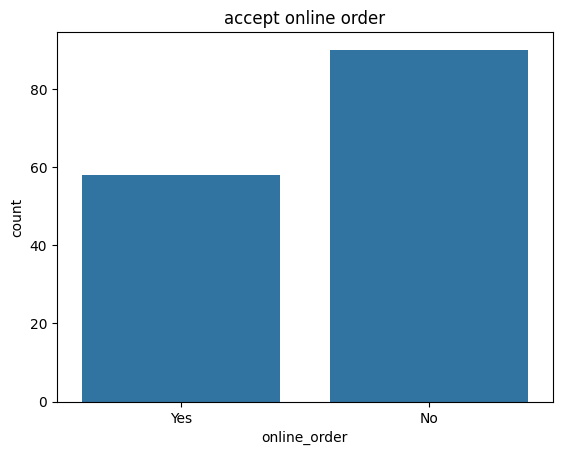

In [33]:
sns.countplot(x=df['online_order'])
plt.title('accept online order')
plt.show()

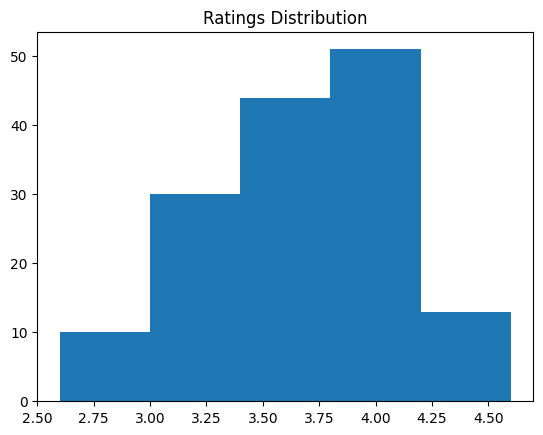

In [35]:
plt.hist(df['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

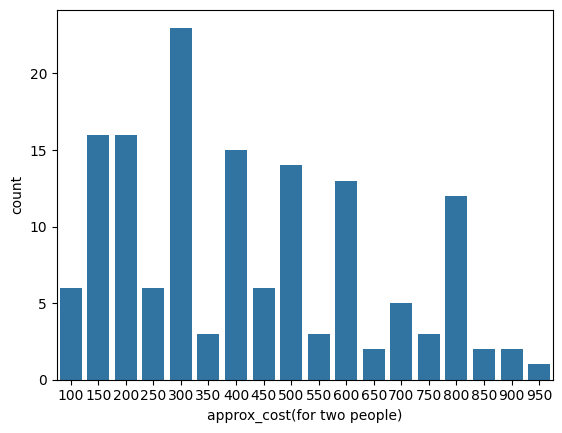

In [36]:
couple_data=df['approx_cost(for two people)']
sns.countplot(x=couple_data)

<Axes: xlabel='online_order', ylabel='rate'>

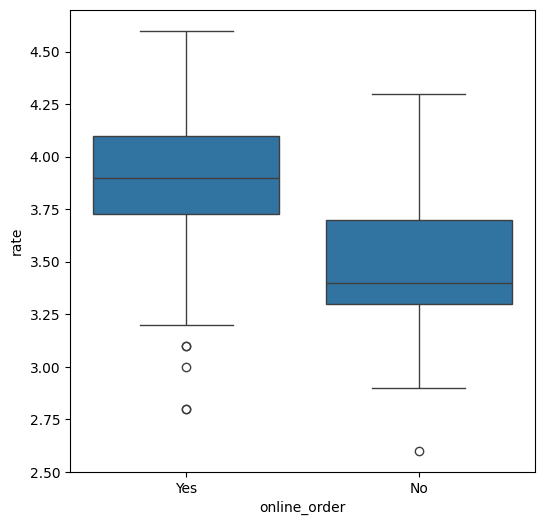

In [37]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df)

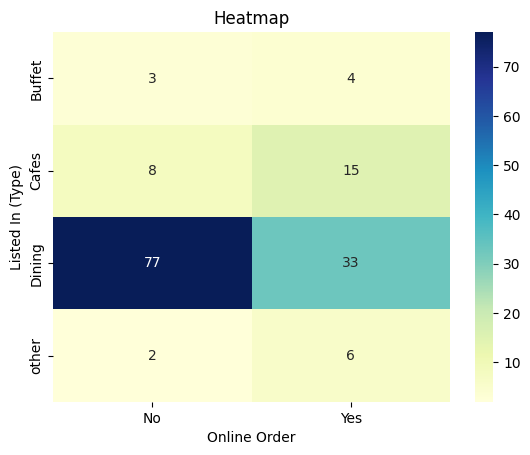

In [39]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()